# Remote UCB optimization — beginner's guide

**Goal:** Run a Jupyter optimization client and an independently managed Xopt HTTP server. This notebook uses the **standard upstream HTTPGenerator**, not cloudpickle.

**Why remote execution?** Scientists can keep notebooks and evaluation workflows on their preferred workstation while an optimization service runs on a dedicated compute node or container. The service can be deployed and monitored separately. In this example the **generator** runs on the server; the **evaluator** still runs in the Jupyter process.

**Development (two terminals on lepton):** In terminal 1, activate `xopt-http-dev` and run `python -m uvicorn cloudpickle_xopt.server:app --host 127.0.0.1 --port 8002`. In terminal 2, start Jupyter using the same environment and execute this notebook. The processes are independent even though they share a host.

**Target (two nodes):** Run the HTTP server inside Docker on a separate trusted machine, expose its port through an appropriate protected network path, and set `XOPT_HTTP_URL=http://SERVER_HOST:8002` in the **Jupyter process environment before launching Jupyter**. `127.0.0.1` means *this machine* and will not reach another node. A Docker container needs a listening address such as `0.0.0.0` plus controlled port publishing; do not expose this experimental cloudpickle-capable server to untrusted networks.

**What is UCB?** Upper Confidence Bound uses a Gaussian-process (GP) prediction and its uncertainty to choose promising experiments. In minimization, the acquisition rule is adjusted to favor low predicted values while exploring uncertain locations. The `beta` setting controls the exploration/exploitation tradeoff. This toy example evaluates a sinusoidal function; no physical apparatus is controlled.


**Cell guide — Import Xopt (optimization controller), VOCS (variables/objectives), Evaluator (runs the test function), and the **upstream** HTTPGenerator (network proxy). `SMOKE_TEST` shortens the number of iterations for a quick check.


In [1]:
import os
import warnings

from xopt import Xopt, VOCS, Evaluator
from xopt.generators.remote.http import HTTPGenerator
from xopt.resources.test_functions.sinusoid_1d import evaluate_sinusoid

warnings.filterwarnings("ignore")
SMOKE_TEST = os.environ.get("SMOKE_TEST", "").lower() in ["1", "true", "yes"]
N_STEPS = 3 if SMOKE_TEST else 8


**Cell guide — Configure the remote address. The default `127.0.0.1:8002` is for two independent processes on the same machine; `XOPT_HTTP_URL` overrides it for another node. The notebook **does not start the server**.


In [2]:
# Start an independent Uvicorn server in another terminal before running.
# This notebook deliberately does not share its Python process with the server.
base_url = os.environ.get("XOPT_HTTP_URL", "http://127.0.0.1:8002")
print(f"Independent HTTPGenerator server: {base_url}")


Independent HTTPGenerator server: http://127.0.0.1:8002


## Build the remote generator and Xopt object

`HTTPGenerator` wraps an already-instantiated generator (here, `UpperConfidenceBoundGenerator`) plus the location of the server (`base_url`). Its full state (including `vocs`) is sent to the server when the session is first created, which reconstructs an instance of the same class there - never by sending a pickled object over the wire.

**Cell guide — Define the experiment: `x1` ranges from 0 to about `2π` radians; `y1` is minimized. UCB builds a GP model from observations. `beta=0.1` sets how strongly uncertainty influences the next candidate. `HTTPGenerator` delegates suggestions to the server; `Evaluator` runs the sinusoid locally.


In [3]:
from xopt.generators.bayesian.upper_confidence_bound import (
    UpperConfidenceBoundGenerator,
)

vocs = VOCS(
    variables={"x1": [0, 6.28]},
    objectives={"y1": "MINIMIZE"},
)

generator = HTTPGenerator(
    base_url=base_url,
    generator=UpperConfidenceBoundGenerator(vocs=vocs, beta=0.1),
)

evaluator = Evaluator(function=evaluate_sinusoid)
X = Xopt(generator=generator, evaluator=evaluator)
X


            Xopt
________________________________
Version: 3.2.3.dev9+g460e28da9
Data size: 0
Config as YAML:
data_dump_file: null
evaluator:
  function: xopt.resources.test_functions.sinusoid_1d.evaluate_sinusoid
  function_kwargs: {}
  max_workers: 1
  vectorized: false
generator:
  api_key: null
  base_url: http://127.0.0.1:8002
  generator:
    beta: 0.1
    computation_time: null
    custom_objective: null
    fixed_features: null
    gp_constructor:
      covar_modules: {}
      custom_noise_prior: null
      mean_modules: {}
      name: standard
      train_config: null
      train_kwargs: null
      train_method: lbfgs
      train_model: true
      trainable_mean_keys: []
      transform_inputs: true
      use_cached_hyperparameters: false
      use_low_noise_prior: false
    max_travel_distances: null
    model: null
    n_candidates: 1
    n_interpolate_points: null
    n_monte_carlo_samples: 128
    numerical_optimizer:
      discrete_max_batch_size: 2048
      discrete_max

## Run optimization

Each `X.step()` call transparently sends the current data to the remote session and asks it to suggest the next point — the optimization loop is identical to running the generator in-process.

**Cell guide — Collect three initial random observations to give the GP some data. Each `X.step()` then requests a remote candidate, evaluates it in Jupyter, and sends the result back to the server. This is an optimization *loop*, not a single HTTP request.


In [4]:
X.random_evaluate(3)
for i in range(N_STEPS):
    print(i)
    X.step()

0
1
2
3
4
5
6
7


## View output data

**Cell guide — Inspect the experiment table. Each row represents an evaluated `x1` and its observed `y1`. The table lives in the notebook-side Xopt object.


In [5]:
X.data

,x1,y1,c1,xopt_runtime,xopt_error
0,5.403390,-0.770609,-17.081795,0.000008,False
1,5.732393,-0.523362,-14.078797,0.000002,False
2,4.645129,-0.997739,-18.586191,0.000001,False
3,4.469369,-0.970616,-19.336130,0.000007,False
4,4.791134,-0.996901,-18.617123,0.000007,False
5,4.747840,-0.999372,-18.524351,0.000007,False
6,4.719580,-0.999974,-18.501008,0.000007,False
7,4.716893,-0.999990,-18.500396,0.000007,False
8,4.715156,-0.999996,-18.500149,0.000007,False
9,4.713948,-0.999999,-18.500047,0.000007,False


## Visualize the remote model

`visualize_model` isn't part of the remote proxy's interface (only `suggest`/`ingest` are). Accessing it triggers `HTTPGenerator` to pull a full, fitted snapshot of the remote generator (including the GP model) and reconstruct a real local copy, then delegate the call to it. This mirror is a read-only, point-in-time snapshot — call `X.generator.pull()` again after more iterations to refresh it.

**Cell guide — Visualize the GP surrogate: the proxy retrieves a generator snapshot and plotting happens **locally**. The model approximates the test function and represents uncertainty; it is not the actual physical process.


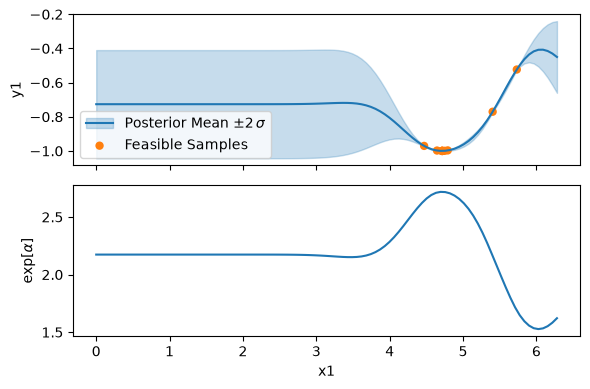

In [6]:
fig, ax = X.generator.visualize_model(n_grid=100)

**Cell guide — Inspect the generator-side observations. This is useful to verify that remote ingestion kept the model data in sync.


In [7]:
X.generator.data

,x1,y1,c1,xopt_runtime,xopt_error
0,5.403390,-0.770609,-17.081795,0.000008,False
1,5.732393,-0.523362,-14.078797,0.000002,False
2,4.645129,-0.997739,-18.586191,0.000001,False
3,4.469369,-0.970616,-19.336130,0.000007,False
4,4.791134,-0.996901,-18.617123,0.000007,False
5,4.747840,-0.999372,-18.524351,0.000007,False
6,4.719580,-0.999974,-18.501008,0.000007,False
7,4.716893,-0.999990,-18.500396,0.000007,False
8,4.715156,-0.999996,-18.500149,0.000007,False
9,4.713948,-0.999999,-18.500047,0.000007,False


**Cell guide — Finalize the **remote session** and free its session state. The separately started Uvicorn service keeps running for the next notebook.


In [8]:
# Finalize the remote session. The independently launched server stays running.
X.generator.finalize()
print("Remote UCB session finalized")


Remote UCB session finalized
